In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("/content/drive/MyDrive/yeast.csv")
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [3]:
df.shape

(1484, 9)

In [4]:
df.dtypes

,0
mcg,float64
gvh,float64
alm,float64
mit,float64
erl,float64
pox,float64
vac,float64
nuc,float64
localization_site,object


># Feature Descriptions

Here’s what each column represents:

| Column | Description |
|--------|-------------|
| `mcg`  | McGeoch’s method for signal sequence recognition |
| `gvh`  | von Heijne’s method for signal sequence recognition |
| `alm`  | ALOM membrane spanning region score |
| `mit`  | Discriminant score for mitochondrial content |
| `erl`  | Presence of ER retention signal (binary) |
| `pox`  | Peroxisomal targeting signal |
| `vac`  | Vacuolar/extracellular content score |
| `nuc`  | Nuclear localization signal score |
| `localization_site` | **Target** – Subcellular localization class |

In [6]:
print(f"Features: {df.columns[:-1]}")

Features: Index(['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc'], dtype='object')


# Class Distribution

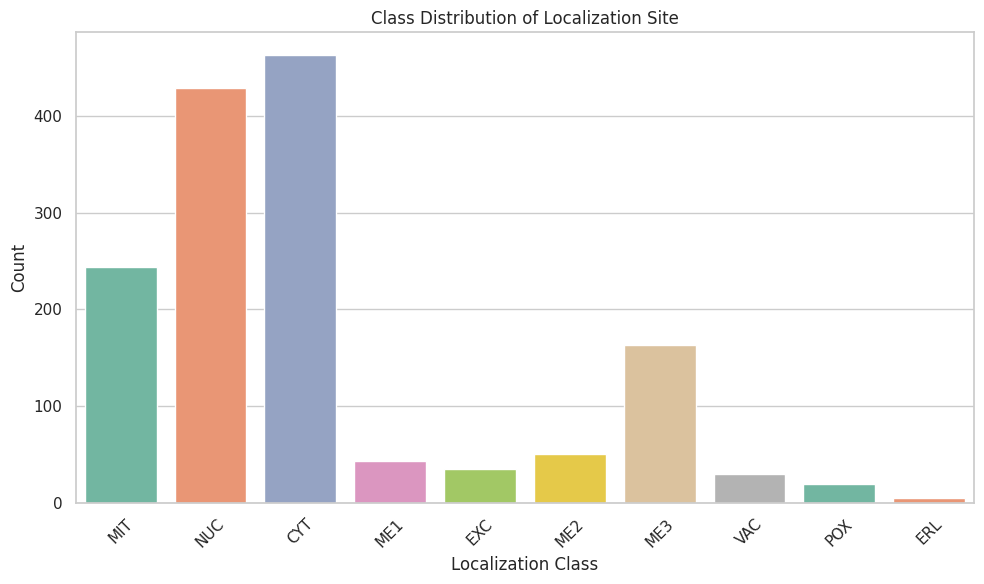

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x="localization_site", data=df, palette="Set2", hue="localization_site")
plt.title("Class Distribution of Localization Site")
plt.xlabel("Localization Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
class_counts = df['localization_site'].value_counts().to_dict()
print(class_counts)

{'CYT': 463, 'NUC': 429, 'MIT': 244, 'ME3': 163, 'ME2': 51, 'ME1': 44, 'EXC': 35, 'VAC': 30, 'POX': 20, 'ERL': 5}


# Feature Distribution

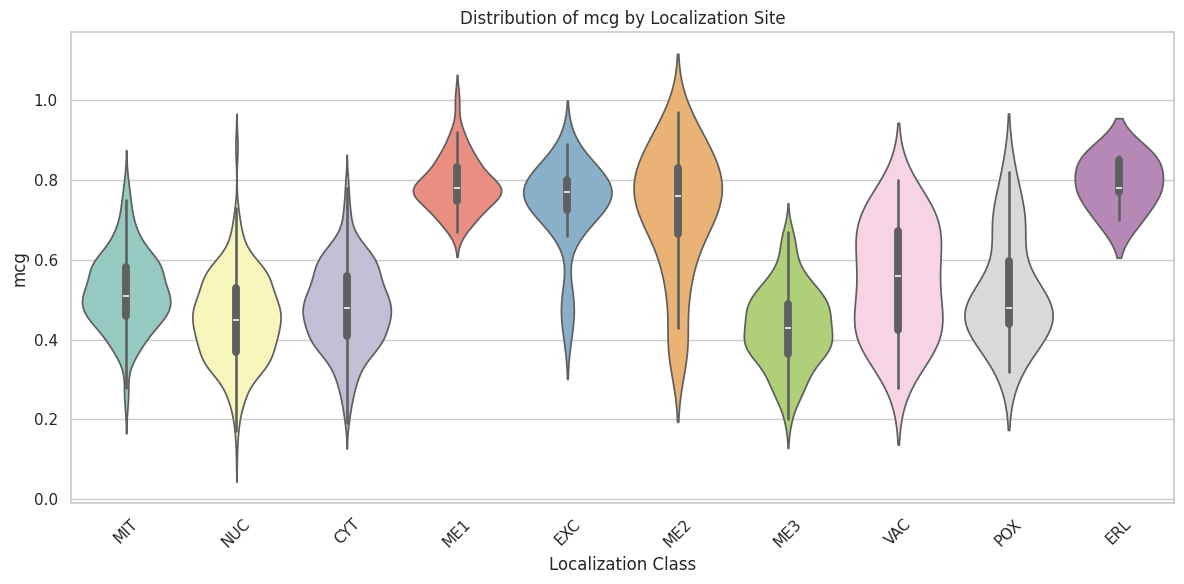

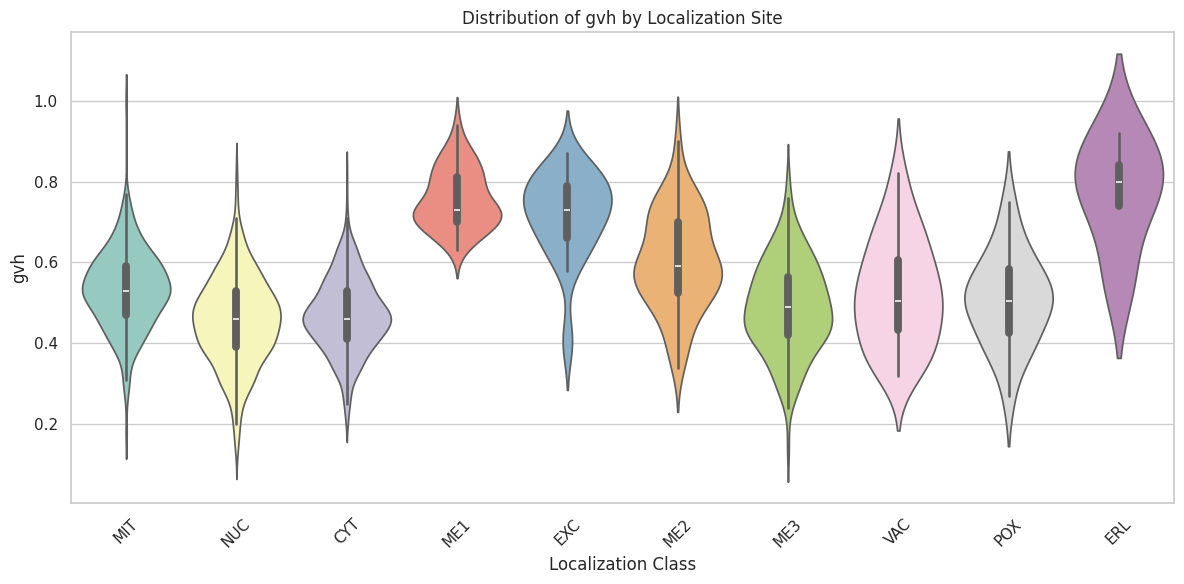

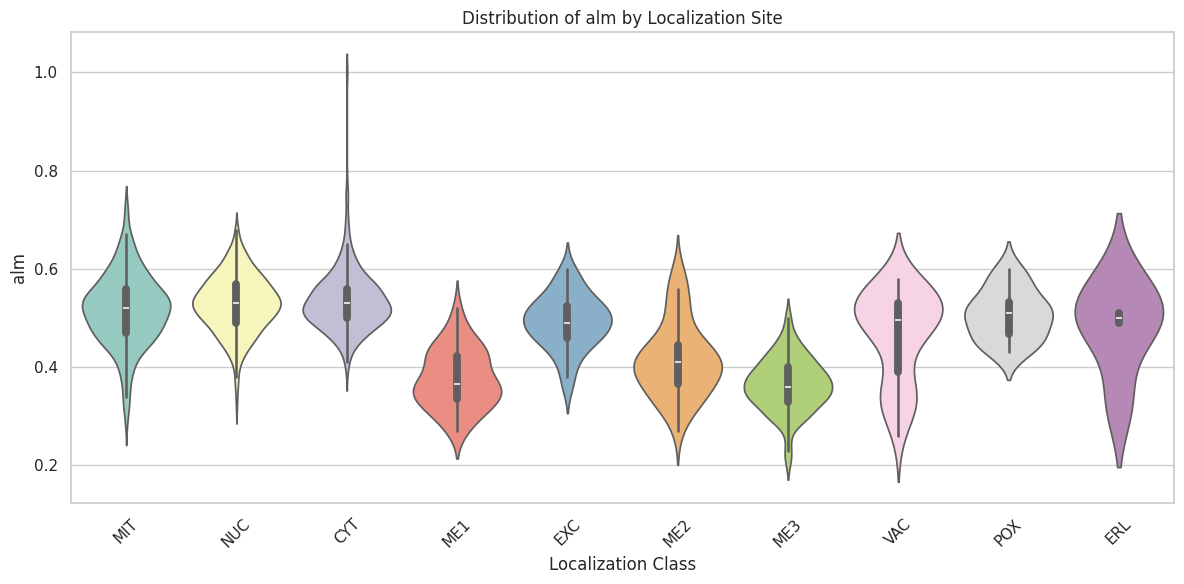

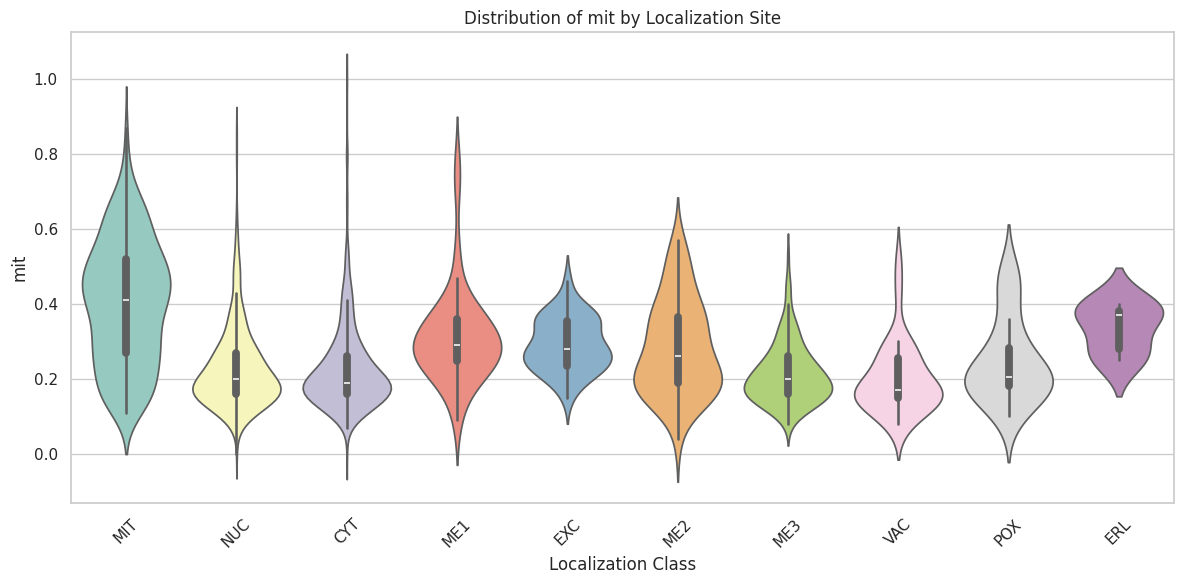

In [12]:
features_to_plot = ['mcg', 'gvh', 'alm', 'mit']

# Set style
sns.set_theme(style="whitegrid")
# Plot feature distributions by class using hue for future compatibility
for feature in features_to_plot:
    plt.figure(figsize=(12, 6))
    sns.violinplot(
        x="localization_site",
        y=feature,
        hue="localization_site",
        data=df,
        inner="box",
        palette="Set3",
        legend=False  # prevents duplicate legend
    )
    plt.title(f"Distribution of {feature} by Localization Site")
    plt.xlabel("Localization Class")
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

From the above violin plots, we can observe several interesting patterns:

- **mcg & gvh**: These two features show clear differentiation for some classes like `ME1`, `ME2`, and `ERL`, where their distributions are tightly packed and significantly shifted from others. This suggests they could be important discriminators for those classes.

- **alm**: This feature appears relatively stable across classes, but with subtle shifts. For example, `CYT`, `ME1`, and `VAC` show higher median values, suggesting some degree of separation potential.

- **mit**: The feature shows **notable variation** across classes. For instance, `MIT` and `ERL` tend to have higher values compared to `NUC`, `CYT`, or `VAC`. Since `mit` relates to mitochondrial proteins, its higher concentration in the `MIT` class is biologically consistent and useful for prediction.

- **General Observation**:
  - Classes like `ME1`, `ME2`, and `ERL` often have **more distinct feature profiles**, suggesting they may be easier to classify if the model learns the patterns correctly.
  - Other classes such as `CYT`, `NUC`, and `MIT` have overlapping distributions for many features, indicating possible **classification challenges** or a need for **feature interactions** to achieve good separation.

➡️ These patterns reinforce why we need **non-linear decision boundaries** and **deep learning models** — to capture subtle, multi-feature interactions that simpler classifiers might miss.

---

# Pearson Correlation Coefficient

The most common measure of correlation is the **Pearson correlation coefficient**:

$$
r = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}
$$

- $r = +1$: perfect positive correlation  
- $r = -1$: perfect negative correlation  
- $r = 0$: no linear correlation

In [13]:
feature_cols = ['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']
corr_matrix = df[feature_cols].corr()

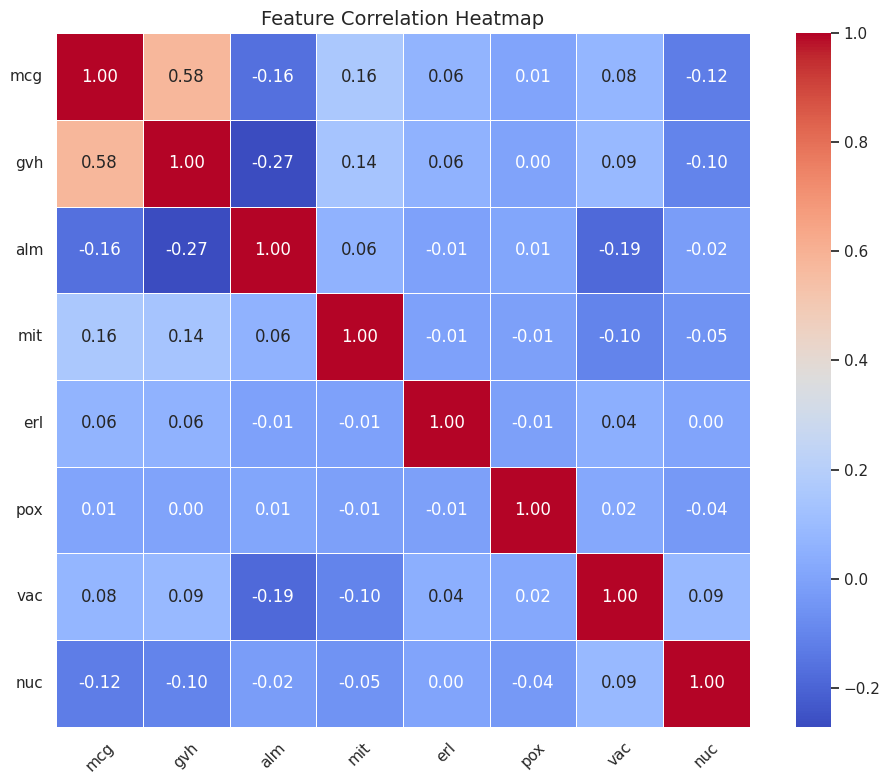

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
feature_cols = df.drop("localization_site", axis=1).columns
print(feature_cols)

Index(['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc'], dtype='object')


In [18]:
label_encoder = LabelEncoder()

target_numeric = label_encoder.fit_transform(df.iloc[:, -1])

CT_df_corr = df[feature_cols].copy()
CT_df_corr["label_numeric"] = target_numeric


CT_feature_target_corr = CT_df_corr.corr()["label_numeric"].drop("label_numeric")

print("CT_Feature-target correlations:")
print(CT_feature_target_corr)

CT_Feature-target correlations:
mcg   -0.082527
gvh   -0.020542
alm   -0.102315
mit    0.109051
erl   -0.052257
pox    0.102067
vac    0.007111
nuc    0.178026
Name: label_numeric, dtype: float64


In [20]:
df['localization_site'] = label_encoder.fit_transform(df['localization_site'])

In [21]:
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,6
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,6
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,6
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,7
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,6


In [22]:
df['localization_site'].value_counts()

,count
localization_site,
0,463
7,429
6,244
5,163
4,51
3,44
2,35
9,30
8,20


# Softmax Function

`logits = [2.0, 1.0, 0.1]`

Let’s apply the **softmax** formula step by step:

> Step 1: Exponentiate the logits  
$$
e^{2.0} = 7.389,\quad e^{1.0} = 2.718,\quad e^{0.1} = 1.105
$$

>Step 2: Sum the exponentiated values  
$$
\text{sum} = 7.389 + 2.718 + 1.105 = 11.212
$$

>Step 3: Divide each by the sum  
$$
P(\text{class 1}) = \frac{7.389}{11.212} \approx 0.659 \\
P(\text{class 2}) = \frac{2.718}{11.212} \approx 0.242 \\
P(\text{class 3}) = \frac{1.105}{11.212} \approx 0.099
$$

So, the model predicts **class 1** with the highest confidence, assigning it ~66% probability.

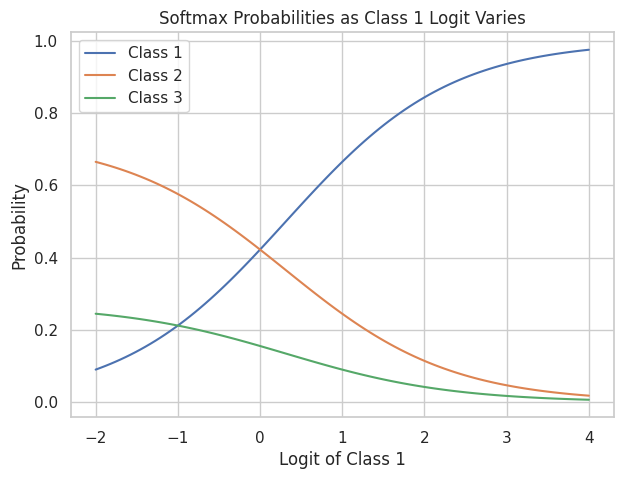

In [23]:
def softmax(logits):
    exp_vals = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)


z_vals = np.linspace(-2, 4, 100)
logits_list = [[z, 0, -1] for z in z_vals]
logits_array = np.array(logits_list)

probs = softmax(logits_array)

plt.figure(figsize=(7, 5))
plt.plot(z_vals, probs[:, 0], label="Class 1")
plt.plot(z_vals, probs[:, 1], label="Class 2")
plt.plot(z_vals, probs[:, 2], label="Class 3")
plt.xlabel("Logit of Class 1")
plt.ylabel("Probability")
plt.title("Softmax Probabilities as Class 1 Logit Varies")
plt.legend()
plt.grid(True)
plt.show()


>**General Formula for Cross-Entropy Loss**

When using **one-hot encoded labels**, the general formula is:

$$
\mathcal{L}_{\text{CE}} = -\sum_{k=1}^{K} y_k \log(\hat{p}_k)
$$

Where:
- $K$ = number of classes  
- $y_k \in \{0, 1\}$: 1 if class $k$ is the true class, 0 otherwise  
- $\hat{p}_k$: predicted probability for class $k$

Only one of the $y_k$ values is 1 (for the true class), so this simplifies to:

$$
\mathcal{L}_{\text{CE}} = -\log(\hat{p}_{\text{true class}})
$$

>**Numerical Example**

Let’s say the true class is class 2, and the model outputs the following softmax probabilities:

$$
[\hat{p}_1, \hat{p}_2, \hat{p}_3] = [0.1, 0.8, 0.1]
$$

Then:

$$
\mathcal{L} = -\log(0.8) \approx 0.22
$$

Now imagine the model is confident but wrong:

$$
[\hat{p}_1, \hat{p}_2, \hat{p}_3] = [0.7, 0.2, 0.1]
$$

Then:

$$
\mathcal{L} = -\log(0.2) \approx 1.61
$$


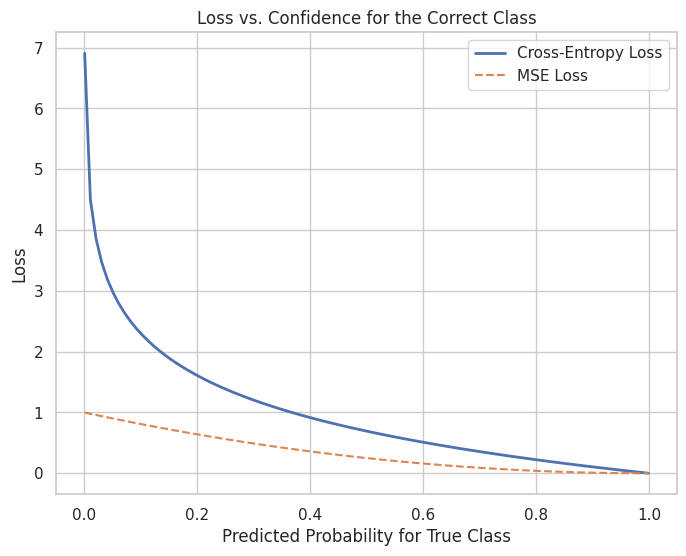

In [24]:
p = np.linspace(0.001, 0.999, 100)

# Loss calculations
cross_entropy = -np.log(p)
mse = (1 - p)**2

# Plot
plt.figure(figsize=(8, 6))
plt.plot(p, cross_entropy, label='Cross-Entropy Loss', linewidth=2)
plt.plot(p, mse, label='MSE Loss', linestyle='--')
plt.xlabel("Predicted Probability for True Class")
plt.ylabel("Loss")
plt.title("Loss vs. Confidence for the Correct Class")
plt.legend()
plt.grid(True)
plt.show()


This plot compares Cross-Entropy Loss (solid blue) and Mean Squared Error (MSE) loss (dashed orange) as a function of the predicted probability assigned to the true class.

- 🟦 Cross-Entropy Loss drops sharply as the model becomes more confident (i.e., predicted probability approaches 1).
    But when the model assigns low probability to the correct class (i.e., it’s confidently wrong), the loss skyrockets — this acts as a strong penalty to push the model to improve.

- 🟧 MSE Loss also decreases as confidence increases, but much more slowly. It doesn’t punish incorrect predictions as strongly, which can lead to slower learning or models that don’t become as confident.

➡️ Key Insight:
Cross-entropy encourages the model to be confident and correct, and it penalizes confident mistakes more harshly, which leads to better gradient signals during training. That’s why it’s the standard choice for classification problems, especially when combined with softmax outputs.

# Evaluation Metrics for Multiclass Classification

After training a classification model, we need to **evaluate how well it performs**.  
In multiclass classification, we go beyond just **accuracy** to get a deeper understanding of model behavior.

Let’s explore the most important metrics:

## 1. Accuracy:
 $ \text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$

- Measures the overall proportion of correct predictions.
- Doesn’t tell us **which classes are being confused**.


## 2. Recall (a.k.a. Sensitivity / True Positive Rate):

 $\text{Recall}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Negatives}_c}$

- Out of all **actual class** \( c \) samples, how many were correctly predicted?
- Measures the model’s ability to **catch** true instances of a class.


## 3. Precision (a.k.a. Positive Predictive Value):

$\text{Precision}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Positives}_c}$

- Out of all samples **predicted as class** \( c \), how many were actually correct?
- Tells us how much we can **trust the model’s predictions** for a class.


## 4. Specificity (a.k.a. True Negative Rate):

$\text{Specificity}_c = \frac{\text{True Negatives}_c}{\text{True Negatives}_c + \text{False Positives}_c}$

- Out of all samples **not belonging to class** \( c \), how many were correctly rejected?
- Important when false alarms are costly.

## 5. F1 Score:

$\text{F1}_c = 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$

- Balances both precision and recall.
- Useful when we care about **both completeness and correctness**.


## 6. Confusion Matrix**

The **confusion matrix** shows how predictions are distributed:

- **Rows**: Actual labels  
- **Columns**: Predicted labels  
- Diagonal = correct predictions  
- Off-diagonal = misclassifications


## 7. Averaging Methods in Multiclass Metrics

In multiclass settings, we summarize metrics across all classes using:

- **Macro average**: Treats all classes equally.  
- **Weighted average**: Weights each class by how frequent it is.  
- **Micro average**: Aggregates total TP, FP, FN globally (treats as binary).


> **📚 Binary Classification Example**

|                          | Predicted: Positive | Predicted: Negative |
|--------------------------|---------------------|---------------------|
| **Actual: Positive (1)** | 40 (TP)             | 10 (FN)             |
| **Actual: Negative (0)** | 30 (FP)             | 120 (TN)            |

**Now compute:**

- **Accuracy**: $\frac{TP + TN}{TP + TN + FP + FN} = \frac{40 + 120}{200} = 0.80$

- **Precision**: $\frac{TP}{TP + FP} = \frac{40}{40 + 30} \approx 0.571$

- **Recall (Sensitivity)**: $\frac{TP}{TP + FN} = \frac{40}{40 + 10} = 0.80$

- **Specificity**: $\frac{TN}{TN + FP} = \frac{120}{120 + 30} = 0.80$

- **F1 Score**: $2 \cdot \frac{0.571 \cdot 0.80}{0.571 + 0.80} \approx 0.666$

> 🔍 **Insight**: Accuracy looks good, but low precision indicates many **false positives**. F1 gives a more realistic picture of model performance.


> **📊 Multiclass Example**

Confusion matrix:

|              | Pred: A | Pred: B | Pred: C |
|--------------|---------|---------|---------|
| **Actual A** | 30      | 5       | 5       |
| **Actual B** | 10      | 25      | 5       |
| **Actual C** | 0       | 10      | 20      |

**Per-class Precision**:

- A: $\frac{30}{30 + 10} = 0.75$

- B: $\frac{25}{25 + 5 + 10} = 0.625$

- C:  $\frac{20}{20 + 10} = 0.666$

**Per-class Recall**:

- A: $\frac{30}{30 + 5 + 5} = 0.75$

- B: $\frac{25}{25 + 10 + 5} = 0.625$

- C: $\frac{20}{20 + 10} = 0.666$

**Macro Precision**: $\frac{0.75 + 0.625 + 0.666}{3} \approx 0.68$

**Macro Recall**: $\frac{0.75 + 0.625 + 0.666}{3} \approx 0.68$

> 🎯 **Insight**: Macro metrics treat all classes equally — useful when class balance is important. Weighted metrics may better reflect true performance when classes are imbalanced.

> **🧠 Terminology Bridge for Bio/ML Students**

| Clinical/Bio Name       | ML Equivalent              |
|-------------------------|----------------------------|
| **Sensitivity**         | **Recall**                 |
| **Specificity**         | **True Negative Rate**     |
| **Precision**           | **Positive Predictive Value (PPV)** |

Throughout this project, we’ll focus on **precision**, **recall**, **F1**, and confusion matrices because they generalize well to **multiclass problems** and are common in machine learning workflows.


Let’s now compute these metrics using some example actual classes against predictions:
